# Phase 1 - EDA & Data Cleaning

In [482]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option("display.max_columns",None)

In [483]:
df1= pd.read_excel("PGCB_date_power_demand.xlsx")
df1.tail()

,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,india_adani,nepal,remarks
92645,2025-06-17 04:00:00,12698.0,12698,0,6030,834,3610,172,0.0,42.0,924,38,1010.0,38.0,NaN
92646,2025-06-17 03:00:00,13280.0,13280,0,6347,999,3698,172,0.0,40.0,924,38,1024.0,38.0,NaN
92647,2025-06-17 02:00:00,13719.0,13719,0,6340,1196,3881,172,0.0,27.0,924,36,1105.0,38.0,NaN
92648,2025-06-17 01:00:00,14093.0,14115,21,6323,1350,4019,172,0.0,28.0,924,38,1201.0,38.0,NaN
92649,2025-06-17 00:00:00,14628.0,14650,21,6302,1672,4186,172,0.0,41.0,924,42,1251.0,38.0,NaN


In [484]:
df2 = pd.read_excel("weather_data.xlsx")
df2.head(10)

,latitude,longitude,elevation,utc_offset_seconds,timezone,timezone_abbreviation,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,23.7961,90.3805,9,21600,Asia/Dhaka,GMT+6,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,time,temperature_2m (°C),relative_humidity_2m (%),apparent_temperature (°C),precipitation (mm),dew_point_2m (°C),soil_temperature_0_to_7cm (°C),wind_direction_10m (°),cloud_cover (%),sunshine_duration (s)
3,2014-01-01 00:00:00,13.9,89,13.3,0,12.1,16.4,313,0,0
4,2014-01-01 01:00:00,13.6,91,13.2,0,12.1,16,317,0,0
5,2014-01-01 02:00:00,13.3,91,12.8,0,11.9,15.7,317,0,0
6,2014-01-01 03:00:00,13,92,12.5,0,11.8,15.4,319,0,0
7,2014-01-01 04:00:00,12.7,93,12.2,0,11.6,15.2,322,0,0
8,2014-01-01 05:00:00,12.4,94,11.9,0,11.5,14.9,324,0,0
9,2014-01-01 06:00:00,12,95,11.2,0,11.2,14.6,325,0,0


In [485]:
df2.columns = df2.iloc[2] 

df2 = df2[3:] 

df2 = df2.reset_index(drop=True)
df2.columns.name = None
df2.head()

,time,temperature_2m (°C),relative_humidity_2m (%),apparent_temperature (°C),precipitation (mm),dew_point_2m (°C),soil_temperature_0_to_7cm (°C),wind_direction_10m (°),cloud_cover (%),sunshine_duration (s)
0,2014-01-01 00:00:00,13.9,89,13.3,0,12.1,16.4,313,0,0
1,2014-01-01 01:00:00,13.6,91,13.2,0,12.1,16,317,0,0
2,2014-01-01 02:00:00,13.3,91,12.8,0,11.9,15.7,317,0,0
3,2014-01-01 03:00:00,13,92,12.5,0,11.8,15.4,319,0,0
4,2014-01-01 04:00:00,12.7,93,12.2,0,11.6,15.2,322,0,0


In [486]:
print(df1.shape, " ", df2.shape)

(92650, 15)   (107304, 10)


In [487]:
df2 = df2.rename(columns={'time': 'datetime'})
print(df1.dtypes)
df2.dtypes



datetime                datetime64[ns]
generation_mw                  float64
demand_mw                        int64
load_shedding                    int64
gas                              int64
liquid_fuel                      int64
coal                             int64
hydro                            int64
solar                          float64
wind                           float64
india_bheramara_hvdc             int64
india_tripura                    int64
india_adani                    float64
nepal                          float64
remarks                         object
dtype: object


datetime                          object
temperature_2m (°C)               object
relative_humidity_2m (%)          object
apparent_temperature (°C)         object
precipitation (mm)                object
dew_point_2m (°C)                 object
soil_temperature_0_to_7cm (°C)    object
wind_direction_10m (°)            object
cloud_cover (%)                   object
sunshine_duration (s)             object
dtype: object

#### Convert time -> from object to datetime, and the rest of columns in df2 to float/int from obj

In [488]:
df2['datetime'] = pd.to_datetime(df2['datetime'])


In [489]:
cols_to_convert = ['temperature_2m (°C)', 'relative_humidity_2m (%)', 'apparent_temperature (°C)', 'precipitation (mm)', 'dew_point_2m (°C)', 'soil_temperature_0_to_7cm (°C)', 'wind_direction_10m (°)', 'cloud_cover (%)', 'sunshine_duration (s)']

# Apply pd.to_numeric to each column, coercing errors to NaN
df2[cols_to_convert] = df2[cols_to_convert].apply(pd.to_numeric, errors='coerce')

#### The rows in df1 are not in proper order, I would them to be sorted 

In [490]:
df1 = df1.sort_values(by='datetime')
df1.tail(5)

,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,india_adani,nepal,remarks
92641,2025-06-17 08:00:00,11896.0,11896,0,5678,490,3470,132,219.0,57.0,924,24,864.0,38.0,NaN
92640,2025-06-17 09:00:00,12290.0,12290,0,6065,531,3491,132,203.0,16.0,924,24,866.0,38.0,NaN
92639,2025-06-17 10:00:00,12443.0,12443,0,5900,552,3601,172,215.0,31.0,923,26,985.0,38.0,NaN
92638,2025-06-17 11:00:00,12826.0,12826,0,5896,595,3591,172,324.0,37.0,924,26,1223.0,38.0,Day_Peak
92637,2025-06-17 12:00:00,13139.0,13139,0,5879,724,3712,172,320.0,53.0,924,28,1289.0,38.0,NaN


the number of rows are inconsistent in df1 and df2, I can merge them by selecting common rows and just keeping them in a new data frame 

In [491]:
df1['datetime'] = pd.to_datetime(df1['datetime'])
df2['datetime'] = pd.to_datetime(df2['datetime'])

# 2. Execute the Merge
# 'how="inner"' ensures only rows with matching timestamps in BOTH datasets are kept.
df = pd.merge(df1, df2, on='datetime', how='inner')
print(df.shape)
df.sample(10)

(88469, 24)


,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,india_adani,nepal,remarks,temperature_2m (°C),relative_humidity_2m (%),apparent_temperature (°C),precipitation (mm),dew_point_2m (°C),soil_temperature_0_to_7cm (°C),wind_direction_10m (°),cloud_cover (%),sunshine_duration (s)
70583,2023-06-03 01:00:00,11797.0,13750,1865,6758,1913,2133,0,0.0,4.0,926,152,NaN,NaN,NaN,28.0,86,33.3,0.0,25.4,30.9,175,0,0.0
10550,2016-06-30 12:00:00,7825.0,7825,0,4819,2231,168,77,NaN,NaN,455,80,NaN,NaN,NaN,31.7,70,37.6,0.2,25.5,33.3,166,100,3600.0
7728,2016-03-06 04:00:00,5721.0,5721,0,4298,801,88,76,NaN,NaN,458,0,NaN,NaN,NaN,22.4,96,26.6,0.0,21.7,24.3,105,10,0.0
81669,2024-09-07 05:00:00,12073.0,12700,599,4823,1655,3429,209,5.0,0.0,878,56,1011.0,NaN,NaN,26.0,95,32.3,0.0,25.2,27.6,175,100,0.0
85567,2025-02-16 15:00:00,10397.0,10397,0,4819,1382,2186,40,208.0,9.0,920,72,761.0,0.0,NaN,30.3,26,28.1,0.0,8.8,32.7,247,0,3600.0
4520,2015-10-25 10:00:00,6025.0,6025,0,4268,946,122,238,NaN,NaN,451,0,NaN,NaN,NaN,28.6,51,31.3,0.0,17.6,28.9,20,0,3600.0
3171,2015-08-30 17:00:00,6413.0,6413,0,4180,1375,170,233,NaN,NaN,455,0,NaN,NaN,NaN,27.5,91,33.1,6.3,25.9,29.6,166,99,0.0
54874,2021-08-18 01:00:00,11242.0,11242,0,6959,2704,624,122,0.0,NaN,713,134,NaN,NaN,NaN,26.1,93,30.4,0.0,24.9,26.5,156,64,0.0
19459,2017-07-28 13:00:00,6955.0,6955,0,4492,2111,73,163,NaN,NaN,0,116,NaN,NaN,NaN,28.9,81,34.8,6.1,25.4,32.0,196,95,3600.0
61889,2022-06-05 22:00:00,13771.0,13771,0,5498,5854,1313,35,0.0,NaN,930,158,NaN,NaN,NaN,28.4,86,33.4,0.0,25.8,28.9,166,41,0.0


OHE the remarks column

In [492]:
df = pd.get_dummies(df, columns=['remarks'])
df.sample(10)

,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,india_adani,nepal,temperature_2m (°C),relative_humidity_2m (%),apparent_temperature (°C),precipitation (mm),dew_point_2m (°C),soil_temperature_0_to_7cm (°C),wind_direction_10m (°),cloud_cover (%),sunshine_duration (s),remarks_Day_Peak,remarks_Evening_Peak
12895,2016-10-05 09:00:00,7214.0,7214,0,4553,1763,165,212,NaN,NaN,458,66,NaN,NaN,27.8,88,34.2,0.1,25.5,29.3,148,88,3024.57,False,False
31387,2018-12-10 20:00:00,7951.0,7951,0,5824,1146,150,42,0.0,NaN,696,110,NaN,NaN,17.9,66,16.8,0.0,11.4,20.4,10,0,0.00,False,False
15596,2017-02-15 22:00:00,6579.0,6579,0,4100,1737,84,92,NaN,NaN,487,88,NaN,NaN,19.9,67,19.9,0.0,13.6,22.5,309,94,0.00,False,False
71372,2023-07-05 22:00:00,13220.0,13650,411,6489,3938,1690,30,0.0,21.0,934,144,NaN,NaN,28.0,86,32.9,0.0,25.4,29.0,142,100,0.00,False,False
47610,2020-10-19 09:00:00,9627.0,9627,0,6044,1804,620,117,25.0,NaN,930,98,NaN,NaN,28.9,84,35.9,0.1,25.9,30.1,51,44,3600.00,False,False
76642,2024-02-10 17:00:00,9797.0,9797,51,4251,1345,3124,46,0.0,7.0,900,124,NaN,NaN,23.8,52,23.6,0.0,13.4,23.8,298,0,3600.00,False,False
1578,2015-06-26 06:00:00,4456.0,4456,0,3269,552,159,40,NaN,NaN,436,0,NaN,NaN,25.6,96,30.2,0.6,25.0,26.3,291,100,0.00,False,False
73104,2023-09-16 04:00:00,12071.0,12500,410,6358,977,3457,198,0.0,0.0,925,156,NaN,NaN,25.6,98,31.9,0.0,25.3,27.4,145,5,0.00,False,False
11716,2016-08-17 16:00:00,6658.0,6658,0,4391,1585,0,172,NaN,NaN,447,68,NaN,NaN,28.4,79,30.9,0.1,24.4,29.9,131,91,3307.60,False,False
18413,2017-06-15 04:00:00,7508.0,7508,0,4881,1793,156,80,NaN,NaN,479,116,NaN,NaN,27.0,90,31.9,0.0,25.1,28.1,166,82,0.00,False,False


Reading the economic dataset

In [493]:
df3 = pd.read_csv("economic_full_1.csv")
df3.head()

,Country Name,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,X,"Intentional homicides, male (per 100,000 male)",VC.IHR.PSRC.MA.P5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,X,Battle-related deaths (number of people),VC.BTL.DETH,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,26.000000,45.000000,25.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,62.000000,57.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,41.000000,47.000000,NaN,NaN,2.000000,NaN,2.000000,NaN,2.000000,NaN
2,X,Voice and Accountability: Percentile Rank,VA.PER.RNK,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,50.000000,NaN,47.263683,NaN,44.776119,NaN,37.313435,31.840796,27.884615,30.288462,32.211540,31.250000,33.173077,38.388626,36.966824,36.150234,34.741783,34.741783,32.019703,30.049261,30.541872,30.049261,27.184465,26.570047,26.570047,28.019323,28.019323,27.450981,NaN,NaN
3,X,Transport services (% of commercial service ex...,TX.VAL.TRAN.ZS.WT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28.891353,31.881229,25.356398,28.035955,22.818176,23.092774,14.354791,16.347633,16.710434,14.932957,12.515757,13.124788,12.929416,12.721805,12.948579,10.370807,10.429827,9.762589,13.152802,14.98295,35.857466,34.054101,36.568027,35.407735,32.180526,29.503600,26.777458,14.821547,16.835488,16.295788,9.983813,8.168923,10.683500,15.170216,14.217416,19.455311,27.917838,32.545223,23.905528,23.938111,20.820301,21.484188,22.048898,19.559759,22.257010,27.162699,25.520411,17.176637,23.495141,NaN
4,X,"Computer, communications and other services (%...",TX.VAL.OTHR.ZS.WT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,63.583179,58.179809,67.113239,62.001316,67.936763,70.528074,70.703822,61.603364,66.002299,73.775462,79.783370,81.344349,81.204968,80.323887,80.588643,83.564321,83.186992,83.416202,81.624655,79.58021,43.536648,37.766478,37.020636,38.190707,44.215626,46.239064,52.655580,67.340668,65.136817,70.824661,77.597275,81.291891,78.751694,72.224917,75.356085,69.732655,59.189573,54.908579,62.323794,62.897128,64.068305,57.202109,62.313903,63.578283,67.395621,64.565856,63.537174,67.817057,65.566600,NaN


In [494]:
df.head(10)

,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,india_adani,nepal,temperature_2m (°C),relative_humidity_2m (%),apparent_temperature (°C),precipitation (mm),dew_point_2m (°C),soil_temperature_0_to_7cm (°C),wind_direction_10m (°),cloud_cover (%),sunshine_duration (s),remarks_Day_Peak,remarks_Evening_Peak
0,2015-04-19 00:00:00,4821.0,4821,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,25.7,87,29.6,0.0,23.5,26.7,188,9,0.00,False,False
1,2015-04-19 01:00:00,3612.0,3612,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,25.3,88,30.0,0.0,23.2,26.4,151,26,0.00,False,False
2,2015-04-19 02:00:00,3727.0,3727,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,24.9,90,29.6,0.0,23.2,26.1,152,32,0.00,False,False
3,2015-04-19 03:00:00,3632.0,3632,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,25.0,90,29.3,0.0,23.3,26.1,171,30,0.00,False,False
4,2015-04-19 04:00:00,3641.0,3641,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,25.2,91,30.3,0.0,23.5,26.0,184,67,0.00,False,False
5,2015-04-19 05:00:00,3283.0,3283,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,24.9,92,30.2,0.0,23.6,25.9,114,78,0.00,False,False
6,2015-04-19 06:00:00,3444.0,3444,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,24.3,96,28.9,1.1,23.6,25.9,80,100,0.00,False,False
7,2015-04-19 07:00:00,3592.0,3592,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,24.0,97,28.2,4.6,23.5,26.5,94,97,2201.58,False,False
8,2015-04-19 08:00:00,4049.0,4049,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,24.2,96,27.9,2.4,23.5,26.5,135,92,724.65,False,False
9,2015-04-19 09:00:00,4488.0,4488,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,25.9,87,29.9,0.0,23.5,27.1,156,59,3600.00,False,False


In [495]:
list(df3.columns)

['Country Name',
 'Indicator Name',
 'Indicator Code',
 '1960',
 '1961',
 '1962',
 '1963',
 '1964',
 '1965',
 '1966',
 '1967',
 '1968',
 '1969',
 '1970',
 '1971',
 '1972',
 '1973',
 '1974',
 '1975',
 '1976',
 '1977',
 '1978',
 '1979',
 '1980',
 '1981',
 '1982',
 '1983',
 '1984',
 '1985',
 '1986',
 '1987',
 '1988',
 '1989',
 '1990',
 '1991',
 '1992',
 '1993',
 '1994',
 '1995',
 '1996',
 '1997',
 '1998',
 '1999',
 '2000',
 '2001',
 '2002',
 '2003',
 '2004',
 '2005',
 '2006',
 '2007',
 '2008',
 '2009',
 '2010',
 '2011',
 '2012',
 '2013',
 '2014',
 '2015',
 '2016',
 '2017',
 '2018',
 '2019',
 '2020',
 '2021',
 '2022',
 '2023',
 '2024',
 '2025']

Since the df starts from 2015, lets just remove the coulumns till 2014

In [496]:
df3.drop(columns=["Indicator Name",'Country Name','1960',
 '1961',
 '1962',
 '1963',
 '1964',
 '1965',
 '1966',
 '1967',
 '1968',
 '1969',
 '1970',
 '1971',
 '1972',
 '1973',
 '1974',
 '1975',
 '1976',
 '1977',
 '1978',
 '1979',
 '1980',
 '1981',
 '1982',
 '1983',
 '1984',
 '1985',
 '1986',
 '1987',
 '1988',
 '1989',
 '1990',
 '1991',
 '1992',
 '1993',
 '1994',
 '1995',
 '1996',
 '1997',
 '1998',
 '1999',
 '2000',
 '2001',
 '2002',
 '2003',
 '2004',
 '2005',
 '2006',
 '2007',
 '2008',
 '2009',
 '2010',
 '2011',
 '2012',
 '2013',
 '2014'], inplace=True)
df3.head(5)

,Indicator Code,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,VC.IHR.PSRC.MA.P5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,VC.BTL.DETH,NaN,41.000000,47.000000,NaN,NaN,2.000000,NaN,2.000000,NaN,2.000000,NaN
2,VA.PER.RNK,30.049261,30.541872,30.049261,27.184465,26.570047,26.570047,28.019323,28.019323,27.450981,NaN,NaN
3,TX.VAL.TRAN.ZS.WT,23.938111,20.820301,21.484188,22.048898,19.559759,22.257010,27.162699,25.520411,17.176637,23.495141,NaN
4,TX.VAL.OTHR.ZS.WT,62.897128,64.068305,57.202109,62.313903,63.578283,67.395621,64.565856,63.537174,67.817057,65.566600,NaN


In [497]:
df3.shape

(1516, 12)

In [498]:
df3.sample(10)

,Indicator Code,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
407,EN.GHG.CH4.MT.CE.AR5,68.652800,68.789000,7.028890e+01,70.466100,7.115580e+01,7.282800e+01,7.429160e+01,7.498120e+01,7.107760e+01,70.455400,NaN
1031,SE.XPD.TOTL.GB.ZS,12.044103,11.049450,NaN,14.245172,8.732970e+00,1.503070e+01,1.276998e+01,1.240404e+01,1.300122e+01,11.993016,11.883438
478,SH.STA.OWGH.ZS,1.400000,NaN,NaN,2.200000,2.400000e+00,NaN,NaN,1.600000e+00,NaN,NaN,NaN
925,DT.NFL.UNWN.CD,NaN,NaN,NaN,NaN,NaN,NaN,1.165180e+06,1.081616e+06,1.555319e+06,NaN,NaN
1100,IE.PPN.TRAN.CD,NaN,NaN,1.795800e+08,NaN,9.092600e+08,1.240000e+09,NaN,3.775300e+08,2.610000e+08,NaN,NaN
103,SH.STA.POIS.P5.FE,0.096000,0.094000,9.800000e-02,0.094000,9.700000e-02,9.600000e-02,1.000000e-01,NaN,NaN,NaN,NaN
623,SL.EMP.VULN.MA.ZS,51.953341,51.470443,5.082031e+01,51.242494,5.164374e+01,5.298747e+01,5.345760e+01,5.357347e+01,5.414736e+01,53.926518,53.594999
460,SP.POP.6064.MA.5Y,2.731556,2.821481,2.912035e+00,2.992194,3.048066e+00,3.082575e+00,3.096688e+00,3.112479e+00,3.142258e+00,3.170636,NaN
1362,BX.GSR.CMCP.ZS,75.391779,72.997935,6.798877e+01,70.191975,7.142154e+01,7.161359e+01,6.012624e+01,5.974085e+01,6.070848e+01,63.890336,NaN
431,TX.VAL.MRCH.R6.ZS,0.557537,0.461707,6.484355e-01,0.619018,5.334322e-01,6.704023e-01,7.598618e-01,6.293197e-01,6.756681e-01,NaN,NaN


In [499]:
# Step 1: Set the Indicator Code as the index FIRST
df3 = df3.set_index('Indicator Code')

# Step 2: NOW transpose the dataframe
df3 = df3.T

# Check your work
df3.head()

Indicator Code  VC.IHR.PSRC.MA.P5  VC.BTL.DETH  VA.PER.RNK  TX.VAL.TRAN.ZS.WT  \
2015                          NaN          NaN   30.049261          23.938111   
2016                          NaN         41.0   30.541872          20.820301   
2017                          NaN         47.0   30.049261          21.484188   
2018                          NaN          NaN   27.184465          22.048898   
2019                          NaN          NaN   26.570047          19.559759   

Indicator Code  TX.VAL.OTHR.ZS.WT  TX.VAL.MRCH.RS.ZS  TX.VAL.MRCH.R3.ZS  \
2015                    62.897128       9.670000e-16           1.258865   
2016                    64.068305      -9.610000e-16           1.025531   
2017                    57.202109       0.000000e+00           1.121373   
2018                    62.313903       0.000000e+00           1.419835   
2019                    63.578283       0.000000e+00           1.437874   

Indicator Code  TX.VAL.MRCH.HI.ZS  TX.VAL.MANF.ZS.UN  TX.VAL.FOOD.ZS.UN  \
2015                    88.632249          95.812302           2.705993   
2016                    88.472454          95.023407           3.035675   
2017                    88.910973          95.197935           3.112666   
2018                    89.007687          94.453053           3.387093   
2019                    89.087427                NaN                NaN   

Indicator Code  TX.MNF.TECH.ZS.UN  TM.VAL.SERV.CD.WT  TM.VAL.MRCH.WL.CD  \
2015                     1.869678       7.391614e+09       3.610139e+10   
2016                     1.869678       7.600060e+09       3.798730e+10   
2017                     1.869678       8.275138e+09       4.424890e+10   
2018                     1.869678       9.271707e+09       5.142856e+10   
2019                     1.869678       9.333944e+09       5.130330e+10   

Indicator Code  TM.VAL.MRCH.R4.ZS  TM.VAL.MRCH.OR.ZS  TM.VAL.MMTL.ZS.UN  \
2015                     0.965739          43.864096           2.682702   
2016                     0.906661          44.965332           3.099198   
2017                     0.527515          43.897282           3.677035   
2018                     0.538271          44.939445           3.791819   
2019                     0.838233          45.868458                NaN   

Indicator Code  TM.VAL.FUEL.ZS.UN  TM.TAX.TCOM.WM.FN.ZS  TM.TAX.TCOM.BR.ZS  \
2015                    10.861586                  7.33             178.99   
2016                    10.539156                  8.02             178.99   
2017                    10.420749                   NaN                NaN   
2018                    10.121532                   NaN                NaN   
2019                          NaN                  5.10             179.79   

Indicator Code  TM.TAX.MRCH.SM.FN.ZS  TM.TAX.MANF.WM.FN.ZS  TM.TAX.MANF.BR.ZS  \
2015                           13.88                 13.87              69.18   
2016                           13.88                 12.79              69.18   
2017                             NaN                   NaN                NaN   
2018                             NaN                   NaN                NaN   
2019                           14.04                 11.99              69.82   

Indicator Code  ST.INT.XPND.MP.ZS  ST.INT.TRNX.CD  ST.INT.DPRT  SP.URB.TOTL  \
2015                     1.814561     400000000.0          NaN   47081010.0   
2016                     1.750125     359000000.0          NaN   48043194.0   
2017                     1.985381     524000000.0          NaN   48982779.0   
2018                     1.840354     452000000.0          NaN   49903270.0   
2019                     2.162418     469000000.0          NaN   50830886.0   

Indicator Code  SP.RUR.TOTL  SP.REG.BRTH.RU.ZS  SP.POP.TOTL.MA.IN  \
2015            112302169.0                NaN         78528055.0   
2016            112768738.0                NaN         79091607.0   
2017            113203368.0                NaN         79723871.0   
20

In [500]:
df3 = df3.reset_index(names='year')

In [501]:
df3.head()

Indicator Code  year  VC.IHR.PSRC.MA.P5  VC.BTL.DETH  VA.PER.RNK  \
0               2015                NaN          NaN   30.049261   
1               2016                NaN         41.0   30.541872   
2               2017                NaN         47.0   30.049261   
3               2018                NaN          NaN   27.184465   
4               2019                NaN          NaN   26.570047   

Indicator Code  TX.VAL.TRAN.ZS.WT  TX.VAL.OTHR.ZS.WT  TX.VAL.MRCH.RS.ZS  \
0                       23.938111          62.897128       9.670000e-16   
1                       20.820301          64.068305      -9.610000e-16   
2                       21.484188          57.202109       0.000000e+00   
3                       22.048898          62.313903       0.000000e+00   
4                       19.559759          63.578283       0.000000e+00   

Indicator Code  TX.VAL.MRCH.R3.ZS  TX.VAL.MRCH.HI.ZS  TX.VAL.MANF.ZS.UN  \
0                        1.258865          88.632249          95.812302   
1                        1.025531          88.472454          95.023407   
2                        1.121373          88.910973          95.197935   
3                        1.419835          89.007687          94.453053   
4                        1.437874          89.087427                NaN   

Indicator Code  TX.VAL.FOOD.ZS.UN  TX.MNF.TECH.ZS.UN  TM.VAL.SERV.CD.WT  \
0                        2.705993           1.869678       7.391614e+09   
1                        3.035675           1.869678       7.600060e+09   
2                        3.112666           1.869678       8.275138e+09   
3                        3.387093           1.869678       9.271707e+09   
4                             NaN           1.869678       9.333944e+09   

Indicator Code  TM.VAL.MRCH.WL.CD  TM.VAL.MRCH.R4.ZS  TM.VAL.MRCH.OR.ZS  \
0                    3.610139e+10           0.965739          43.864096   
1                    3.798730e+10           0.906661          44.965332   
2                    4.424890e+10           0.527515          43.897282   
3                    5.142856e+10           0.538271          44.939445   
4                    5.130330e+10           0.838233          45.868458   

Indicator Code  TM.VAL.MMTL.ZS.UN  TM.VAL.FUEL.ZS.UN  TM.TAX.TCOM.WM.FN.ZS  \
0                        2.682702          10.861586                  7.33   
1                        3.099198          10.539156                  8.02   
2                        3.677035          10.420749                   NaN   
3                        3.791819          10.121532                   NaN   
4                             NaN                NaN                  5.10   

Indicator Code  TM.TAX.TCOM.BR.ZS  TM.TAX.MRCH.SM.FN.ZS  TM.TAX.MANF.WM.FN.ZS  \
0                          178.99                 13.88                 13.87   
1                          178.99                 13.88                 12.79   
2                             NaN                   NaN                   NaN   
3                             NaN                   NaN                   NaN   
4                          179.79                 14.04                 11.99   

Indicator Code  TM.TAX.MANF.BR.ZS  ST.INT.XPND.MP.ZS  ST.INT.TRNX.CD  \
0                           69.18           1.814561     400000000.0   
1                           69.18           1.750125     359000000.0   
2                             NaN           1.985381     524000000.0   
3                             NaN           1.840354     452000000.0   
4                           69.82           2.162418     469000000.0   

Indicator Code  ST.INT.DPRT  SP.URB.TOTL  SP.RUR.TOTL  SP.REG.BRTH.RU.ZS  \
0                       NaN   47081010.0  112302169.0                NaN   
1                       NaN   48043194.0  112768738.0                NaN   
2                       NaN   48982779.0  113203368.0                NaN   
3                       NaN   49903270.0  113619833.0               24.9   
4                 

In [502]:
df3.dtypes

Indicator Code
year                  object
VC.IHR.PSRC.MA.P5    float64
VC.BTL.DETH          float64
VA.PER.RNK           float64
TX.VAL.TRAN.ZS.WT    float64
                      ...   
DC.DAC.TOTL.CD       float64
DC.DAC.PRTL.CD       float64
DC.DAC.NLDL.CD       float64
DC.DAC.JPNL.CD       float64
DC.DAC.HUNL.CD       float64
Length: 1517, dtype: object

In [503]:
df3['year'] = df3['year'].astype(int)

There's a Large number of columns in df3, I cannot just merge it now, first I need to select the important columns, I can't directly use correlation, as the frequencies dont match, To find the best features we can use Random forest right now, but only on data till 2023 to avoid data leakage, 24,25 will be left as testing data

In [504]:
from sklearn.ensemble import RandomForestRegressor

# ---------------------------------------------------------
# 1. Chronological Split (Strictly <= 2023)
# ---------------------------------------------------------
# Extract the year from the datetime column and slice the training regime
train_df = df[df['datetime'].dt.year <= 2023].copy()
train_df['year'] = train_df['datetime'].dt.year

# Broadcast the annual economic data to the hourly training set
train_df = pd.merge(train_df, df3, on='year', how='left')

# Identify the economic columns (excluding the 'year' merge key)
econ_cols = [col for col in df3.columns if col != 'year']

# ---------------------------------------------------------
# 2. Data Preparation (Bypassing the ValueError)
# ---------------------------------------------------------
# Forward-fill then back-fill the economic columns to patch World Bank reporting gaps.
# This prevents dropna() from deleting the entire dataset.
train_df[econ_cols] = train_df[econ_cols].ffill().bfill()

# Now, ONLY drop rows if the actual target variable is missing
eval_df = train_df.dropna(subset=['demand_mw'])

# Define feature matrix (X) and target vector (y)
X_train = eval_df[econ_cols]
y_train = eval_df['demand_mw']

print(f"Samples successfully loaded for training: {len(X_train)}")

# ---------------------------------------------------------
# 3. Train the Random Forest
# ---------------------------------------------------------
# max_depth=10 prevents the model from overfitting on static annual step-functions
rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Extract and sort the Variance Reduction scores
importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)

print("\n--- Top 10 Macroeconomic Drivers ---")
print(importances.head(10))

# ---------------------------------------------------------
# 4. Apply the Benchmark & Clean df3
# ---------------------------------------------------------
# Benchmark: Feature must contribute at least 1% (0.01) to the model's decisions
threshold = 0.01

# Filter for columns that meet the benchmark
important_econ_cols = importances[importances >= threshold].index.tolist()

# Keep 'year' so you can still merge this cleanly later
cols_to_keep = ['year'] + important_econ_cols

# Permanently overwrite your economic dataset to only include the strong signals
df3 = df3[cols_to_keep]

print(f"\nReduced economic dataset from {len(econ_cols)} to {len(important_econ_cols)} features.")

Samples successfully loaded for training: 75665

--- Top 10 Macroeconomic Drivers ---
NV.IND.TOTL.CN       0.016833
ER.FSH.AQUA.MT       0.015122
AG.PRD.LVSK.XD       0.015055
PA.NUS.ATLS          0.014886
NE.IMP.GNFS.KD       0.014763
SP.POP.0014.FE.ZS    0.014732
NE.GDI.TOTL.CN       0.014589
DC.DAC.GBRL.CD       0.010970
SP.RUR.TOTL.ZS       0.010899
FM.LBL.BMNY.CN       0.009638
dtype: float64

Reduced economic dataset from 1516 to 9 features.


Merging it into the df dataframe

In [505]:
# 1. Align the keys
df['year'] = df['datetime'].dt.year
df['year'] = df['year'].astype(int)
df3['year'] = df3['year'].astype(int)

# 2. OVERWRITE df with the merged data
df = pd.merge(df, df3, on='year', how='left')

# 3. Handle the 2024-2025 missing data by forward-filling the 2023 values
important_econ_cols = [col for col in df3.columns if col != 'year']
df[important_econ_cols] = df[important_econ_cols].ffill().bfill()

# Verify it actually worked on df
print("Current columns in df:")
print(df.columns.tolist())

Current columns in df:
['datetime', 'generation_mw', 'demand_mw', 'load_shedding', 'gas', 'liquid_fuel', 'coal', 'hydro', 'solar', 'wind', 'india_bheramara_hvdc', 'india_tripura', 'india_adani', 'nepal', 'temperature_2m (°C)', 'relative_humidity_2m (%)', 'apparent_temperature (°C)', 'precipitation (mm)', 'dew_point_2m (°C)', 'soil_temperature_0_to_7cm (°C)', 'wind_direction_10m (°)', 'cloud_cover (%)', 'sunshine_duration (s)', 'remarks_Day_Peak', 'remarks_Evening_Peak', 'year', 'NV.IND.TOTL.CN', 'ER.FSH.AQUA.MT', 'AG.PRD.LVSK.XD', 'PA.NUS.ATLS', 'NE.IMP.GNFS.KD', 'SP.POP.0014.FE.ZS', 'NE.GDI.TOTL.CN', 'DC.DAC.GBRL.CD', 'SP.RUR.TOTL.ZS']


In [506]:

df.sample(3)


,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,india_adani,nepal,temperature_2m (°C),relative_humidity_2m (%),apparent_temperature (°C),precipitation (mm),dew_point_2m (°C),soil_temperature_0_to_7cm (°C),wind_direction_10m (°),cloud_cover (%),sunshine_duration (s),remarks_Day_Peak,remarks_Evening_Peak,year,NV.IND.TOTL.CN,ER.FSH.AQUA.MT,AG.PRD.LVSK.XD,PA.NUS.ATLS,NE.IMP.GNFS.KD,SP.POP.0014.FE.ZS,NE.GDI.TOTL.CN,DC.DAC.GBRL.CD,SP.RUR.TOTL.ZS
49881,2021-01-22 00:00:00,6648.0,6648,0,3767,1726,590,46,0.0,NaN,450,78,NaN,NaN,14.9,74,13.8,0.0,10.3,17.4,56,2,0.0,False,False,2021,1.176120e+13,2639185.0,146.31,84.804834,6.002296e+10,27.723886,1.095020e+13,1.199389e+08,68.600784
83118,2024-11-06 13:00:00,11080.0,11080,0,5230,1117,2390,174,489.0,0.0,899,56,725.0,NaN,29.7,59,34.3,0.0,20.7,31.4,100,41,3600.0,False,False,2024,1.705760e+13,2852572.0,153.13,111.140585,6.777685e+10,26.637017,1.535840e+13,7.196305e+07,67.321680
80432,2024-07-17 15:00:00,13294.0,14000,674,5137,1574,5136,200,228.0,11.0,914,94,NaN,NaN,33.8,64,40.8,0.1,26.0,34.7,167,84,3600.0,False,False,2024,1.705760e+13,2852572.0,153.13,111.140585,6.777685e+10,26.637017,1.535840e+13,7.196305e+07,67.321680


In [507]:
df.shape

(88469, 35)

### Now that we have the dataset, lets actually start the EDA process

In [508]:
dup_names = df.columns[df.columns.duplicated()].tolist()
print("Duplicate column names:", dup_names)

# THE FIX: Drop the duplicates, keeping only the first occurrence
#df = df.loc[:, ~df.columns.duplicated(keep='first')]

Duplicate column names: []


removing exact duplicate rows

In [509]:
# View exact identical rows
exact_duplicates = df[df.duplicated(keep=False)]
print("Exact row duplicates:")
print(exact_duplicates)

# Drop exact identical rows, keeping the first
df = df.drop_duplicates()

Exact row duplicates:
                 datetime  generation_mw  demand_mw  load_shedding   gas  \
829   2015-05-26 15:00:00         6421.0       6421              0  3845   
830   2015-05-26 15:00:00         6421.0       6421              0  3845   
1090  2015-06-06 05:00:00         6066.0       6066              0  4252   
1091  2015-06-06 05:00:00         6066.0       6066              0  4252   
1134  2015-06-08 00:00:00         7573.0       7573              0  4389   
...                   ...            ...        ...            ...   ...   
63907 2022-08-28 22:00:00        13364.0      14000            586  6022   
77759 2024-03-28 07:00:00         9820.0       9820              0  4923   
77760 2024-03-28 07:00:00         9820.0       9820              0  4923   
81704 2024-09-08 16:00:00        12411.0      14200           1708  4770   
81705 2024-09-08 16:00:00        12411.0      14200           1708  4770   

       liquid_fuel  coal  hydro  solar  wind  india_bheramara_hvd

In [510]:
# Create a mask for duplicate datetimes. 
# keep=False ensures pandas flags EVERY copy of the duplicate, not just the second one.
duplicate_time_mask = df.duplicated(subset=['datetime'], keep=False)

# View the duplicated rows, sorted by time so you can compare them side-by-side
duplicates_df = df[duplicate_time_mask].sort_values(by='datetime')
print("Duplicate datetime rows:")
print(duplicates_df)

Duplicate datetime rows:
                 datetime  generation_mw  demand_mw  load_shedding   gas  \
70    2015-04-22 21:00:00         5811.0       5811              0  4158   
71    2015-04-22 21:00:00         5368.0       5368              0  4184   
73    2015-04-23 00:00:00         5726.0       5726              0  4199   
74    2015-04-23 00:00:00         3976.0       3976              0  3116   
146   2015-04-27 00:00:00         5236.0       5236              0  4417   
...                   ...            ...        ...            ...   ...   
84951 2025-01-21 23:00:00         9160.0       9160              0  4716   
85693 2025-02-21 22:00:00         9808.0       9808              0  4720   
85694 2025-02-21 22:00:00        10629.0      10629              0  4517   
86246 2025-03-16 23:00:00        14377.0      14405             27  5641   
86247 2025-03-16 23:00:00        13599.0      13730            125  5933   

       liquid_fuel  coal  hydro  solar  wind  india_bheramara_

Taking mean of duplicate datetime rows

In [511]:
# Group the dataset by your datetime column and calculate the mean
# as_index=False ensures 'datetime' remains a standard column instead of becoming the index
df = df.groupby('datetime', as_index=False).mean()

# ⚠️ Note on Data Types: 
# Averaging identical integers (like the 'year' column we created earlier) 
# will convert that column into a float (e.g., 2015.0). 
# Force it back to an integer to keep your types clean:
if 'year' in df.columns:
    df['year'] = df['year'].astype(int)

In [512]:
df.sample(5)

,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,india_adani,nepal,temperature_2m (°C),relative_humidity_2m (%),apparent_temperature (°C),precipitation (mm),dew_point_2m (°C),soil_temperature_0_to_7cm (°C),wind_direction_10m (°),cloud_cover (%),sunshine_duration (s),remarks_Day_Peak,remarks_Evening_Peak,year,NV.IND.TOTL.CN,ER.FSH.AQUA.MT,AG.PRD.LVSK.XD,PA.NUS.ATLS,NE.IMP.GNFS.KD,SP.POP.0014.FE.ZS,NE.GDI.TOTL.CN,DC.DAC.GBRL.CD,SP.RUR.TOTL.ZS
52376,2021-05-20 19:00:00,11644.0,11644.0,0.0,6717.0,3165.0,650.0,25.0,0.0,NaN,932.0,172.0,NaN,NaN,31.5,69.0,37.8,0.0,25.2,31.8,142.0,36.0,0.00,0.0,0.0,2021,1.176120e+13,2639185.0,146.31,84.804834,6.002296e+10,27.723886,1.095020e+13,119938896.2,68.600784
14352,2016-12-12 17:00:00,7210.0,7210.0,0.0,4329.0,2024.0,173.0,90.0,NaN,NaN,497.0,100.0,NaN,NaN,24.2,54.0,24.7,0.0,14.3,25.8,267.0,18.0,3600.00,0.0,0.0,2016,6.449400e+12,2203554.0,104.77,78.266562,4.487226e+10,29.558166,6.277230e+12,200458877.6,70.124608
53516,2021-07-07 09:00:00,10087.0,10087.0,0.0,6495.0,2092.0,530.0,54.0,14.0,NaN,824.0,94.0,NaN,NaN,28.8,87.0,34.5,0.2,26.4,28.6,166.0,98.0,2578.21,0.0,0.0,2021,1.176120e+13,2639185.0,146.31,84.804834,6.002296e+10,27.723886,1.095020e+13,119938896.2,68.600784
43466,2020-05-14 02:00:00,9405.0,9405.0,0.0,6367.0,1113.0,812.0,38.0,0.0,NaN,942.0,144.0,NaN,NaN,26.0,94.0,31.4,0.0,25.0,27.4,138.0,8.0,0.00,0.0,0.0,2020,1.043450e+13,2584256.0,136.86,84.776569,5.207346e+10,28.009873,9.926090e+12,260818176.3,68.883107
60974,2022-05-14 15:00:00,11318.0,11318.0,0.0,5818.0,3468.0,925.0,30.0,53.0,NaN,927.0,108.0,NaN,NaN,33.8,62.0,37.3,0.0,25.5,32.0,195.0,54.0,3600.00,0.0,0.0,2022,1.347210e+13,2731563.0,153.13,86.316950,7.873997e+10,27.370495,1.272830e+13,67397270.2,68.326265


### Missing Data Analysis

In [513]:
import pandas as pd

# Get the raw count of missing values per column
missing_counts = df.isna().sum()

# Calculate the percentage of missing values per column
missing_percentages = (df.isna().sum() / len(df)) * 100

# Combine them into a clean, readable dataframe
missing_summary = pd.DataFrame({
    'Missing Values': missing_counts, 
    'Percentage (%)': missing_percentages
})

# Filter out columns that have 0 missing values to keep the view clean,
# and sort from worst to best
missing_summary = missing_summary[missing_summary['Missing Values'] > 0].sort_values(by='Percentage (%)', ascending=False)

print("--- Missing Value Summary ---")
print(missing_summary)

--- Missing Value Summary ---
             Missing Values  Percentage (%)
nepal                 82913       94.170093
india_adani           81007       92.005315
wind                  70136       79.658360
solar                 20517       23.302592


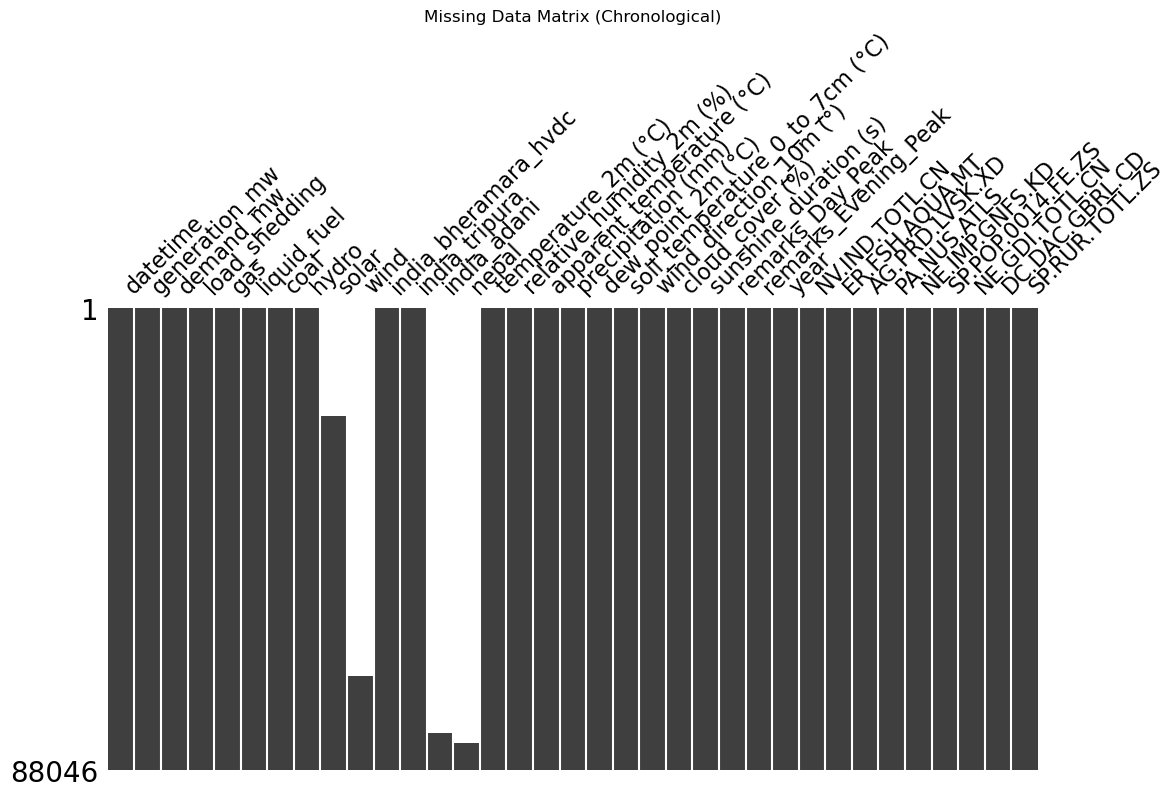

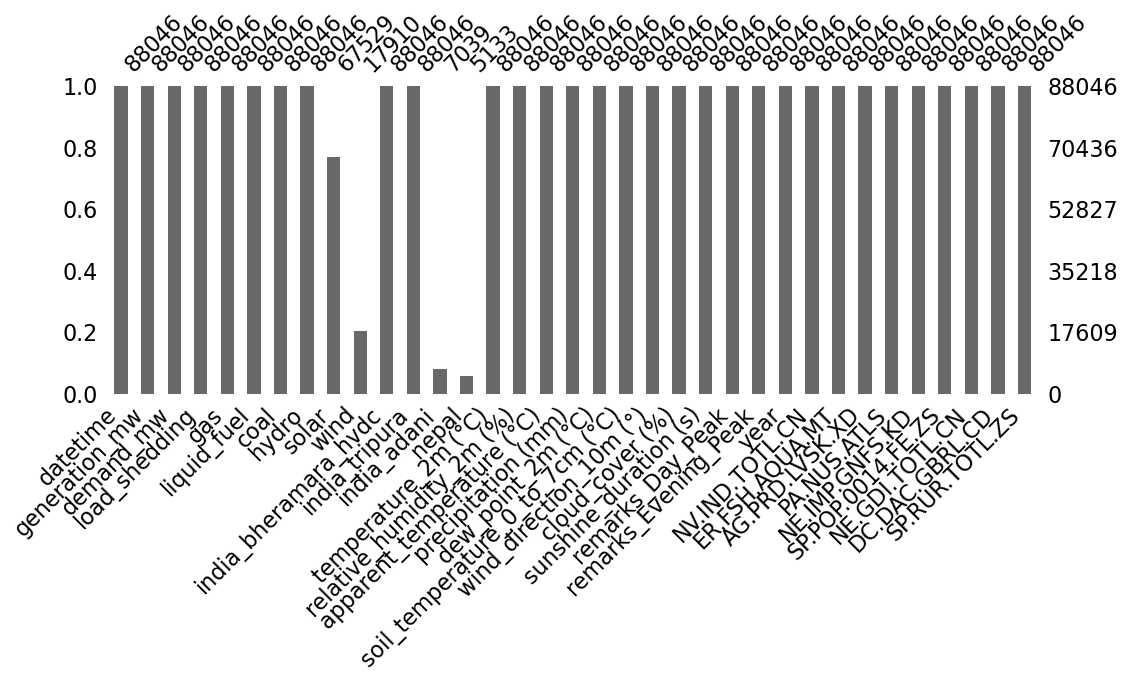

In [514]:
# You might need to install it first: pip install missingno
import missingno as msno
import matplotlib.pyplot as plt

# 1. The Matrix (Best for Time Series)
# This plots your dataset from top to bottom chronologically. 
# White lines represent missing values. If you see a thick white block, 
# that means a sensor went down for an extended period.
msno.matrix(df, figsize=(12, 6), sparkline=False)
plt.title("Missing Data Matrix (Chronological)")
plt.show()

# 2. The Bar Chart
# A visual representation of the completeness of each column
msno.bar(df, figsize=(12, 4))
plt.show()

#### Since the Nepal, india_adani, wind Mostly empty I will just drop them and fill the solar entries using linear interpolation

In [515]:
columns_to_drop = ['nepal', 'india_adani', 'wind']
df = df.drop(columns=columns_to_drop)

df['solar'] = df['solar'].interpolate(method='linear')
df['solar'] = df['solar'].clip(lower=0)
df.head()

,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,india_bheramara_hvdc,india_tripura,temperature_2m (°C),relative_humidity_2m (%),apparent_temperature (°C),precipitation (mm),dew_point_2m (°C),soil_temperature_0_to_7cm (°C),wind_direction_10m (°),cloud_cover (%),sunshine_duration (s),remarks_Day_Peak,remarks_Evening_Peak,year,NV.IND.TOTL.CN,ER.FSH.AQUA.MT,AG.PRD.LVSK.XD,PA.NUS.ATLS,NE.IMP.GNFS.KD,SP.POP.0014.FE.ZS,NE.GDI.TOTL.CN,DC.DAC.GBRL.CD,SP.RUR.TOTL.ZS
0,2015-04-19 00:00:00,4821.0,4821.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,25.7,87.0,29.6,0.0,23.5,26.7,188.0,9.0,0.0,0.0,0.0,2015,4.067110e+12,2060408.0,101.1,77.675052,4.829746e+10,30.219456,4.378650e+12,250109390.3,70.46049
1,2015-04-19 01:00:00,3612.0,3612.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,25.3,88.0,30.0,0.0,23.2,26.4,151.0,26.0,0.0,0.0,0.0,2015,4.067110e+12,2060408.0,101.1,77.675052,4.829746e+10,30.219456,4.378650e+12,250109390.3,70.46049
2,2015-04-19 02:00:00,3727.0,3727.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,24.9,90.0,29.6,0.0,23.2,26.1,152.0,32.0,0.0,0.0,0.0,2015,4.067110e+12,2060408.0,101.1,77.675052,4.829746e+10,30.219456,4.378650e+12,250109390.3,70.46049
3,2015-04-19 03:00:00,3632.0,3632.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,25.0,90.0,29.3,0.0,23.3,26.1,171.0,30.0,0.0,0.0,0.0,2015,4.067110e+12,2060408.0,101.1,77.675052,4.829746e+10,30.219456,4.378650e+12,250109390.3,70.46049
4,2015-04-19 04:00:00,3641.0,3641.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,25.2,91.0,30.3,0.0,23.5,26.0,184.0,67.0,0.0,0.0,0.0,2015,4.067110e+12,2060408.0,101.1,77.675052,4.829746e+10,30.219456,4.378650e+12,250109390.3,70.46049


In [516]:
df['hour'] = df['datetime'].dt.hour
df['month'] = df['datetime'].dt.month

historical_solar_profiles = df.groupby(['month', 'hour'])['solar'].transform('mean')

df['solar'] = df['solar'].fillna(historical_solar_profiles)

df['solar'] = df['solar'].fillna(0)

print("Remaining NaNs in solar after profile imputation:", df['solar'].isna().sum())

Remaining NaNs in solar after profile imputation: 0


In [517]:
df =df.drop(columns = ['hour','month'])

df.head()

,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,india_bheramara_hvdc,india_tripura,temperature_2m (°C),relative_humidity_2m (%),apparent_temperature (°C),precipitation (mm),dew_point_2m (°C),soil_temperature_0_to_7cm (°C),wind_direction_10m (°),cloud_cover (%),sunshine_duration (s),remarks_Day_Peak,remarks_Evening_Peak,year,NV.IND.TOTL.CN,ER.FSH.AQUA.MT,AG.PRD.LVSK.XD,PA.NUS.ATLS,NE.IMP.GNFS.KD,SP.POP.0014.FE.ZS,NE.GDI.TOTL.CN,DC.DAC.GBRL.CD,SP.RUR.TOTL.ZS
0,2015-04-19 00:00:00,4821.0,4821.0,0.0,0.0,0.0,0.0,0.0,0.303138,0.0,0.0,25.7,87.0,29.6,0.0,23.5,26.7,188.0,9.0,0.0,0.0,0.0,2015,4.067110e+12,2060408.0,101.1,77.675052,4.829746e+10,30.219456,4.378650e+12,250109390.3,70.46049
1,2015-04-19 01:00:00,3612.0,3612.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,25.3,88.0,30.0,0.0,23.2,26.4,151.0,26.0,0.0,0.0,0.0,2015,4.067110e+12,2060408.0,101.1,77.675052,4.829746e+10,30.219456,4.378650e+12,250109390.3,70.46049
2,2015-04-19 02:00:00,3727.0,3727.0,0.0,0.0,0.0,0.0,0.0,0.351464,0.0,0.0,24.9,90.0,29.6,0.0,23.2,26.1,152.0,32.0,0.0,0.0,0.0,2015,4.067110e+12,2060408.0,101.1,77.675052,4.829746e+10,30.219456,4.378650e+12,250109390.3,70.46049
3,2015-04-19 03:00:00,3632.0,3632.0,0.0,0.0,0.0,0.0,0.0,0.594142,0.0,0.0,25.0,90.0,29.3,0.0,23.3,26.1,171.0,30.0,0.0,0.0,0.0,2015,4.067110e+12,2060408.0,101.1,77.675052,4.829746e+10,30.219456,4.378650e+12,250109390.3,70.46049
4,2015-04-19 04:00:00,3641.0,3641.0,0.0,0.0,0.0,0.0,0.0,0.336134,0.0,0.0,25.2,91.0,30.3,0.0,23.5,26.0,184.0,67.0,0.0,0.0,0.0,2015,4.067110e+12,2060408.0,101.1,77.675052,4.829746e+10,30.219456,4.378650e+12,250109390.3,70.46049


### Spikes

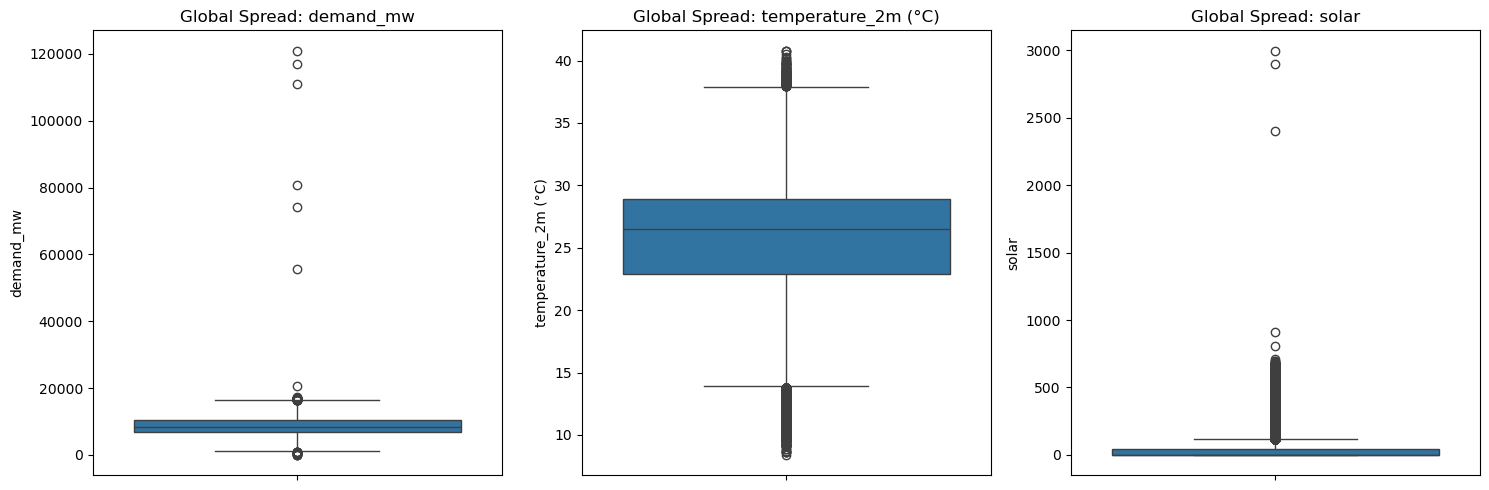

In [518]:
# Select the continuous hourly variables
continuous_cols = ['demand_mw', 'temperature_2m (°C)', 'solar']

plt.figure(figsize=(15, 5))
for i, col in enumerate(continuous_cols, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=df[col])
    plt.title(f'Global Spread: {col}')

plt.tight_layout()
plt.show()

We check weather the demand at a perticular hour is kind of similar to its neighbour or nor if its too different we change it with its neighbours rolling mean

In [519]:
import pandas as pd
import numpy as np

def neutralize_contextual_outliers(dataframe, column, window=48, threshold=3.0):
    """
    Identifies contextual outliers using a rolling Z-score and 
    neutralizes them by replacing the extreme values with the local rolling mean.
    """
    # 1. Calculate local rolling mean and standard deviation
    rolling_mean = dataframe[column].rolling(window=window, center=True, min_periods=1).mean()
    rolling_std = dataframe[column].rolling(window=window, center=True, min_periods=1).std()
    
    # 2. Calculate the Z-score for the specific column
    z_score = (dataframe[column] - rolling_mean) / rolling_std
    
    # 3. Identify outliers
    outlier_mask = z_score.abs() > threshold
    outlier_count = outlier_mask.sum()
    
    print(f"[{column}] Detected {outlier_count} contextual outliers.")
    
    # 4. Neutralize (Winsorize) the outliers to the local mean
    if outlier_count > 0:
        dataframe.loc[outlier_mask, column] = rolling_mean[outlier_mask]
        print(f"[{column}] Successfully neutralized anomalies.")
        
    return dataframe

# --- Execute the cleanup on both target columns ---
print("--- Anomaly Detection & Neutralization ---")

# Clean the demand column
df = neutralize_contextual_outliers(df, 'demand_mw')

# Clean the generation column so it stays mathematically synced
df = neutralize_contextual_outliers(df, 'generation_mw')

--- Anomaly Detection & Neutralization ---
[demand_mw] Detected 59 contextual outliers.
[demand_mw] Successfully neutralized anomalies.
[generation_mw] Detected 14 contextual outliers.
[generation_mw] Successfully neutralized anomalies.


In [520]:
df.shape

(88046, 32)

# Phase 2 : Feature Engineering

In [521]:
if 'datetime' in df.columns:
    df = df.set_index('datetime')

# Sort chronologically to guarantee shifts operate correctly
df = df.sort_index()

df['hour']       = df.index.hour
df['dayofweek']  = df.index.dayofweek   
df['month']      = df.index.month       
df['quarter']    = df.index.quarter     
df['is_weekend'] = (df.index.dayofweek >= 5).astype(int)  
df['dayofyear']  = df.index.dayofyear   


df['hour_sin']  = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos']  = np.cos(2 * np.pi * df['hour'] / 24)

df['dow_sin']   = np.sin(2 * np.pi * df['dayofweek'] / 7)
df['dow_cos']   = np.cos(2 * np.pi * df['dayofweek'] / 7)

df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
lags = [1, 2, 3, 6, 12, 24, 48, 168]

for lag in lags:
    # Shift positive numbers push data down (past -> present)
    df[f'demand_lag_{lag}h'] = df['demand_mw'].shift(lag)

windows = [3, 6, 12, 24, 168]

for window in windows:
    df[f'demand_rolling_mean_{window}h'] = df['demand_mw'].shift(1).rolling(window=window).mean()
    df[f'demand_rolling_std_{window}h']  = df['demand_mw'].shift(1).rolling(window=window).std()

# Shift negative numbers pull data up (future -> present)
df['target'] = df['demand_mw'].shift(-1)

df = df.dropna(subset=['target', 'demand_lag_168h'])

columns_to_drop = ['hour', 'dayofweek', 'month']
df = df.drop(columns=columns_to_drop)

print("--- Feature Engineering Complete ---")
print(f"Final Matrix Shape: {df.shape}")

--- Feature Engineering Complete ---
Final Matrix Shape: (87877, 59)


# Phase 3 : Modelling , Tuning

In [523]:
import optuna
from sklearn.ensemble import RandomForestRegressor
import lightgbm as lgb
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_percentage_error, root_mean_squared_error

In [527]:
# =====================================================================
# PHASE 1: DYNAMIC FEATURE SELECTION (Noise Baseline Only)
# =====================================================================
print("--- PHASE 1: Objective Feature Selection ---")

columns_to_drop = ['target', 'generation_mw']
X_train_full = train_df.drop(columns=columns_to_drop)
y_train_full = train_df['target']

# 1. Inject the "Random Noise" Benchmark
np.random.seed(42)
X_train_full['RANDOM_NOISE_BASELINE'] = np.random.normal(0, 1, size=len(X_train_full))

# 2. Train the Inspector Model
inspector = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
inspector.fit(X_train_full, y_train_full)

# 3. Extract and Sort Importances
importances = pd.Series(inspector.feature_importances_, index=X_train_full.columns)
importances = importances.sort_values(ascending=False)

# 4. Find the Random Noise Threshold
noise_importance = importances['RANDOM_NOISE_BASELINE']
print(f"Random Noise Benchmark scored: {noise_importance:.6f}")

# Keep only features strictly better than random noise
features_beating_noise = importances[importances > noise_importance]
selected_features = features_beating_noise.index.tolist()

print(f"Original features (excluding target/gen): {len(X_train_full.columns) - 1}")
print(f"Final Features retained (beating noise): {len(selected_features)}\n")

print("Top 15 Final Features:")
print(features_beating_noise.head(15))

--- PHASE 1: Objective Feature Selection ---
Random Noise Benchmark scored: 0.000024
Original features (excluding target/gen): 57
Final Features retained (beating noise): 41

Top 15 Final Features:
demand_mw                         0.972850
hour_cos                          0.009168
hour_sin                          0.006241
demand_lag_3h                     0.002009
demand_rolling_mean_24h           0.001447
solar                             0.001209
demand_lag_6h                     0.000891
month_cos                         0.000559
dayofyear                         0.000533
demand_lag_2h                     0.000502
demand_lag_1h                     0.000481
demand_rolling_std_12h            0.000393
demand_lag_12h                    0.000353
demand_rolling_mean_12h           0.000232
soil_temperature_0_to_7cm (°C)    0.000230
dtype: float64


In [ ]:
# import optuna
# import pandas as pd
# import lightgbm as lgb
# from lightgbm import LGBMRegressor
# from sklearn.metrics import mean_absolute_percentage_error
# import warnings

# # Keep the notebook output clean from LightGBM user warnings
# warnings.filterwarnings('ignore')
# optuna.logging.set_verbosity(optuna.logging.WARNING)

# print("--- PHASE 2: Optuna Hyperparameter Tuning ---")

# # ---------------------------------------------------------
# # 1. Strict Chronological Validation Split (Corrected)
# # ---------------------------------------------------------
# # Train on 2015-2022, Validate on 2023 (The year right before the test set)
# train_opt = train_df[train_df.index.year < 2023]   
# val_opt   = train_df[train_df.index.year == 2023]  

# # selected_features is assumed to be in memory from Phase 1
# X_train_opt = train_opt[selected_features]
# y_train_opt = train_opt['target']
# X_val_opt   = val_opt[selected_features]
# y_val_opt   = val_opt['target']

# print(f"Optuna Tuning Train Set (2015-2022): {X_train_opt.shape[0]} hours")
# print(f"Optuna Tuning Val Set   (2023):      {X_val_opt.shape[0]} hours\n")

# # ---------------------------------------------------------
# # 2. Define the Objective Function
# # ---------------------------------------------------------
# def objective(trial):
#     params = {
#         'n_estimators'      : trial.suggest_int('n_estimators', 500, 3000),
#         'learning_rate'     : trial.suggest_float('learning_rate', 0.005, 0.2, log=True),
#         'num_leaves'        : trial.suggest_int('num_leaves', 20, 150),
#         'max_depth'         : trial.suggest_int('max_depth', 4, 12),
#         'min_child_samples' : trial.suggest_int('min_child_samples', 20, 150),
#         'subsample'         : trial.suggest_float('subsample', 0.6, 1.0),
#         'colsample_bytree'  : trial.suggest_float('colsample_bytree', 0.6, 1.0),
#         'reg_alpha'         : trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
#         'reg_lambda'        : trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
#         'random_state'      : 42,
#         'n_jobs'            : -1,
#         'verbosity'         : -1,
#     }

#     model = LGBMRegressor(**params)
    
#     # Train with Early Stopping to prevent overfitting
#     model.fit(
#         X_train_opt, y_train_opt,
#         eval_set=[(X_val_opt, y_val_opt)],
#         callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
#     )

#     preds = model.predict(X_val_opt)
    
#     # Calculate Mean Absolute Percentage Error (MAPE)
#     mape = mean_absolute_percentage_error(y_val_opt, preds) * 100
#     return mape

# # ---------------------------------------------------------
# # 3. Execute Bayesian Search
# # ---------------------------------------------------------
# print("Initializing Bayesian Search (TPE Algorithm)...")
# study = optuna.create_study(direction='minimize')

# # 30 trials is a solid baseline. Increase to 50+ if you need more precision.
# study.optimize(objective, n_trials=30, show_progress_bar=True)

# print("\n--- Optuna Tuning Complete ---")
# print(f"Best Validation MAPE Achieved: {study.best_value:.4f}%")

# # Extract and display the winning parameters
# best_params = study.best_params
# print("\nWinning Hyperparameters Locked In:")
# for key, value in best_params.items():
#     print(f"  {key}: {value}")

--- PHASE 2: Optuna Hyperparameter Tuning ---
Optuna Tuning Train Set (2015-2022): 66351 hours
Optuna Tuning Val Set   (2023):      8737 hours

Initializing Bayesian Search (TPE Algorithm)...


  0%|          | 0/30 [00:00<?, ?it/s]


--- Optuna Tuning Complete ---
Best Validation MAPE Achieved: 2.0723%

Winning Hyperparameters Locked In:
  n_estimators: 1939
  learning_rate: 0.010932281380612096
  num_leaves: 72
  max_depth: 6
  min_child_samples: 85
  subsample: 0.9599112451557461
  colsample_bytree: 0.9969331505183394
  reg_alpha: 0.5507668119352372
  reg_lambda: 0.0025845034963280474


In [529]:
import lightgbm as lgb
from lightgbm import LGBMRegressor

print("--- PHASE 3A: Final Model Training ---")

# 1. Lock in the winning Optuna hyperparameters
best_params = {
    'n_estimators': 1939,
    'learning_rate': 0.010932281380612096,
    'num_leaves': 72,
    'max_depth': 6,
    'min_child_samples': 85,
    'subsample': 0.9599112451557461,
    'colsample_bytree': 0.9969331505183394,
    'reg_alpha': 0.5507668119352372,
    'reg_lambda': 0.0025845034963280474,
    # Static parameters for consistency and silent training
    'random_state': 42,
    'n_jobs': -1,
    'verbosity': -1
}

# 2. Isolate the features and target for the full training timeline (2015 - 2023)
X_train_final = train_df[selected_features]
y_train_final = train_df['target']

# 3. Instantiate the LightGBM Regressor with the optimized architecture
final_model = LGBMRegressor(**best_params)

# 4. Train the final model
print(f"Training LightGBM on {X_train_final.shape[0]} hours of historical grid data...")
final_model.fit(X_train_final, y_train_final)

print("\nTraining Complete! The model weights are mathematically locked.")

--- PHASE 3A: Final Model Training ---
Training LightGBM on 75088 hours of historical grid data...

Training Complete! The model weights are mathematically locked.


--- PHASE 3B: Final Test Evaluation (2024-2025) ---

             FINAL TEST METRICS               
Test MAPE: 2.006%
Test RMSE: 347.01 MW



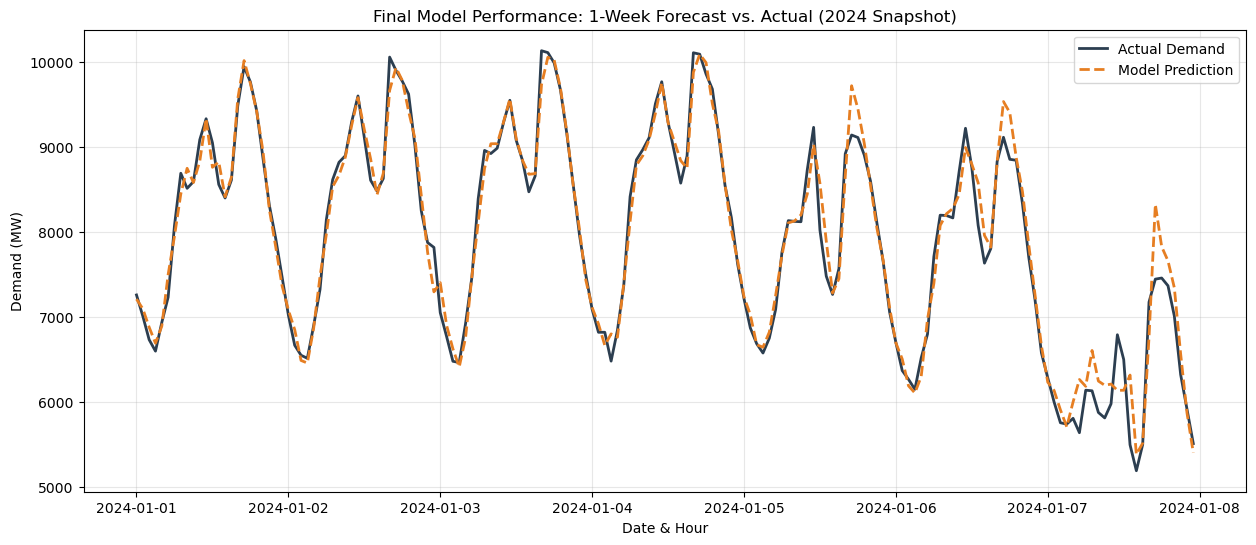

In [530]:
from sklearn.metrics import mean_absolute_percentage_error, root_mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

print("--- PHASE 3B: Final Test Evaluation (2024-2025) ---")

# 1. Prepare the unseen test features and target
X_test_final = test_df[selected_features]
y_test_final = test_df['target']

# 2. Generate predictions for the unseen 2024-2025 period
final_predictions = final_model.predict(X_test_final)

# 3. Calculate Final Performance Metrics
final_mape = mean_absolute_percentage_error(y_test_final, final_predictions) * 100
final_rmse = root_mean_squared_error(y_test_final, final_predictions)

print("\n==============================================")
print("             FINAL TEST METRICS               ")
print("==============================================")
print(f"Test MAPE: {final_mape:.3f}%")
print(f"Test RMSE: {final_rmse:.2f} MW")
print("==============================================\n")

# 4. Visualizing a 1-Week Snapshot of Predictions vs. Actuals
# We'll take a random week in 2024 to see the daily alignment
plt.figure(figsize=(15, 6))

# Plotting the first 168 hours (one full week) of the test set
plt.plot(y_test_final.index[:168], y_test_final.values[:168], 
         label='Actual Demand', color='#2c3e50', linewidth=2)
plt.plot(y_test_final.index[:168], final_predictions[:168], 
         label='Model Prediction', color='#e67e22', linestyle='--', linewidth=2)

plt.title('Final Model Performance: 1-Week Forecast vs. Actual (2024 Snapshot)')
plt.xlabel('Date & Hour')
plt.ylabel('Demand (MW)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()